# Treino do Modelo NumPy (DNN com implementação própria)
Este notebook treina uma Deep Neural Network implementada de raiz em NumPy para classificação multi-classe de texto (Human vs. AI).

In [1]:
import pandas as pd
import numpy as np
import pickle
import re
import sys
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from src.neuralnet import NeuralNetwork
from src.layers import DenseLayer, DropoutLayer
from src.activation import ReLUActivation, SoftmaxActivation
from src.losses import CategoricalCrossEntropy
from src.simple_label_encoder import SimpleLabelEncoder
from src.numpy_text_features import build_vocab_and_idf, transform_tfidf, stratified_train_val_test_split
from src.numpy_eval import (
    confusion_matrix_np,
    accuracy_np,
    macro_metrics,
    weighted_f1,
    balanced_accuracy,
    print_classification_report,
    per_class_precision_recall_f1,
 )

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento e Pré-processamento dos Dados

In [2]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()

df = pd.read_csv("data/train.csv", sep=";")

TARGET_CLASSES = ["Human", "Google", "Meta", "OpenAI", "Mistral"]
available_labels = set(df["Label"].unique().tolist())

if "Mistral" not in available_labels and "Anthropic" in available_labels:
    print("[Aviso] O dataset atual não contém classe 'Mistral'.")
    print("[Aviso] Será usada a classe 'Anthropic' como substituta temporária até recolher dados Mistral.")
    classes_ativas = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]
else:
    classes_ativas = [c for c in TARGET_CLASSES if c in available_labels]

df = df[df["Label"].isin(classes_ativas)].copy()
df["clean_text"] = df["Text"].apply(clean_text)

print(f"Total de exemplos válidos: {len(df)}")
print("\nDistribuição das classes:")
print(df["Label"].value_counts())
print(f"\nClasses ativas: {classes_ativas}")

[Aviso] O dataset atual não contém classe 'Mistral'.
[Aviso] Será usada a classe 'Anthropic' como substituta temporária até recolher dados Mistral.
Total de exemplos válidos: 26500

Distribuição das classes:
Label
Anthropic    5300
Google       5300
OpenAI       5300
Meta         5300
Human        5300
Name: count, dtype: int64

Classes ativas: ['Human', 'Google', 'Meta', 'OpenAI', 'Anthropic']


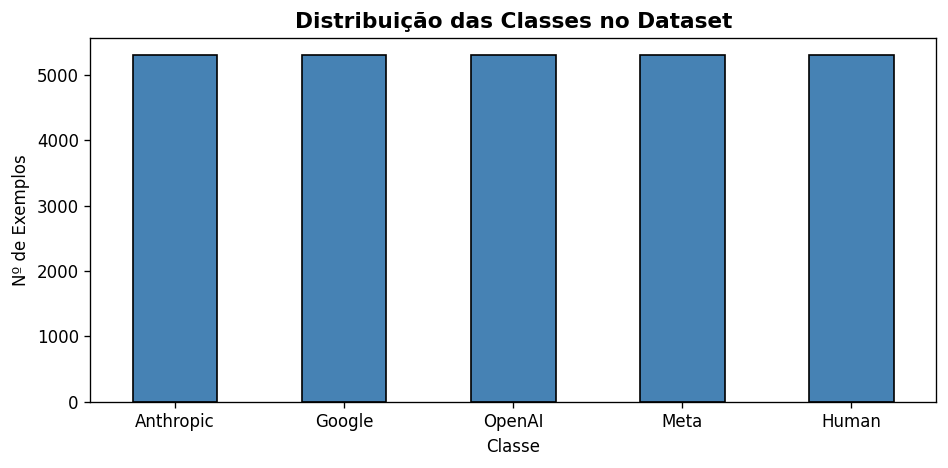

In [3]:
# Visualizar distribuição das classes
fig, ax = plt.subplots(figsize=(8, 4))
df["Label"].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Distribuição das Classes no Dataset", fontsize=13, fontweight='bold')
ax.set_xlabel("Classe")
ax.set_ylabel("Nº de Exemplos")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("plots/numpy_class_distribution.png", bbox_inches='tight')
plt.show()

## 2. Criação das Features (TF-IDF) e Divisão Train/Validation/Test (sem leakage)

In [4]:
le = SimpleLabelEncoder()
le.fit(classes_ativas)
labels_idx = le.transform(df["Label"].tolist())

texts = df["clean_text"].tolist()
vocab, idf = build_vocab_and_idf(texts, max_features=5000, min_df=2)
X_all = transform_tfidf(texts, vocab, idf)

# Divisão treino/validação/teste estratificada (70/15/15)
X_train, X_val, X_test, y_train_idx, y_val_idx, y_test_idx = stratified_train_val_test_split(
    X_all, labels_idx, train_size=0.70, val_size=0.15, seed=RANDOM_SEED
)

# One-Hot Encoding
def to_onehot(idx, n_classes):
    oh = np.zeros((len(idx), n_classes), dtype=np.float32)
    oh[np.arange(len(idx)), idx] = 1.0
    return oh

n_classes = len(le.classes_)
y_train = to_onehot(y_train_idx, n_classes)
y_val   = to_onehot(y_val_idx, n_classes)
y_test  = to_onehot(y_test_idx, n_classes)

print(f"Vocab TF-IDF: {len(vocab)}")
print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Classes: {le.classes_}")

Vocab TF-IDF: 5000
X_train: (18550, 5000) | X_val: (3975, 5000) | X_test: (3975, 5000)
Classes: ['Human' 'Google' 'Meta' 'OpenAI' 'Anthropic']


## 3. Definição e Treino da DNN

In [5]:
# Histórico de treino para análise
history_dnn = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

class NeuralNetworkTracked(NeuralNetwork):
    """Extensão da NeuralNetwork com histórico e early stopping por val_loss."""
    def fit(self, X, y, X_val, y_val, patience=8, min_delta=1e-4, history=None):
        if history is None:
            history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

        n_samples = X.shape[0]
        best_val_loss = float("inf")
        bad_epochs = 0
        best_state = None

        for epoch in range(1, self.epochs + 1):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X[indices[start:end]]
                y_batch = y[indices[start:end]]
                output = self.forward_propagation(X_batch, training=True)
                error = self.loss_func.derivative(y_batch, output)
                self.backward_propagation(error)

            train_pred = self.forward_propagation(X, training=False)
            val_pred = self.forward_propagation(X_val, training=False)

            train_loss = self.loss_func.loss(y, train_pred)
            val_loss = self.loss_func.loss(y_val, val_pred)
            train_acc = np.mean(np.argmax(train_pred, axis=1) == np.argmax(y, axis=1))
            val_acc = np.mean(np.argmax(val_pred, axis=1) == np.argmax(y_val, axis=1))

            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            history["train_acc"].append(train_acc)
            history["val_acc"].append(val_acc)

            if val_loss < (best_val_loss - min_delta):
                best_val_loss = val_loss
                bad_epochs = 0
                best_state = []
                for layer in self.layers:
                    state = {}
                    if hasattr(layer, "weights"):
                        state["weights"] = layer.weights.copy()
                    if hasattr(layer, "biases"):
                        state["biases"] = layer.biases.copy()
                    best_state.append(state)
            else:
                bad_epochs += 1

            if epoch % 5 == 0 or epoch == 1:
                print(
                    f"Epoch {epoch:3d}/{self.epochs} | "
                    f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                    f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
                )

            if bad_epochs >= patience:
                print(f"Early stopping ativado na época {epoch}.")
                break

        if best_state is not None:
            for layer, state in zip(self.layers, best_state):
                if "weights" in state:
                    layer.weights = state["weights"]
                if "biases" in state:
                    layer.biases = state["biases"]

        return history


net = NeuralNetworkTracked(epochs=80, batch_size=16, learning_rate=0.01, momentum=0.9)
net.add(DenseLayer(256, input_shape=(X_train.shape[1],)))
net.add(ReLUActivation())
net.add(DropoutLayer(drop_rate=0.4))
net.add(DenseLayer(128))
net.add(ReLUActivation())
net.add(DropoutLayer(drop_rate=0.3))
net.add(DenseLayer(64))
net.add(ReLUActivation())
net.add(DropoutLayer(drop_rate=0.2))
net.add(DenseLayer(n_classes))
net.add(SoftmaxActivation())

print("A treinar o modelo NumPy DNN...")
history_dnn = net.fit(X_train, y_train, X_val, y_val, patience=10, history=history_dnn)
train_losses = history_dnn["train_loss"]
val_losses = history_dnn["val_loss"]
train_accs = history_dnn["train_acc"]
val_accs = history_dnn["val_acc"]
print("\nTreino concluído!")

A treinar o modelo NumPy DNN...
Epoch   1/80 | Train Loss: 1.6017 Acc: 0.2465 | Val Loss: 1.6017 Acc: 0.2506
Epoch   5/80 | Train Loss: 1.5197 Acc: 0.3422 | Val Loss: 1.5295 Acc: 0.3263
Epoch  10/80 | Train Loss: 1.0843 Acc: 0.5606 | Val Loss: 1.1763 Acc: 0.5097
Epoch  15/80 | Train Loss: 0.9039 Acc: 0.6383 | Val Loss: 1.1300 Acc: 0.5406
Epoch  20/80 | Train Loss: 0.6366 Acc: 0.7499 | Val Loss: 0.9530 Acc: 0.6272
Epoch  25/80 | Train Loss: 0.4908 Acc: 0.8279 | Val Loss: 0.9436 Acc: 0.6551
Epoch  30/80 | Train Loss: 0.3880 Acc: 0.8601 | Val Loss: 0.9311 Acc: 0.6732
Early stopping ativado na época 32.

Treino concluído!


## 3.1 Baseline — Regressão Logística (NumPy puro)

In [6]:
history_baseline = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

baseline = NeuralNetworkTracked(epochs=80, batch_size=16, learning_rate=0.01, momentum=0.9)
baseline.add(DenseLayer(n_classes, input_shape=(X_train.shape[1],)))
baseline.add(SoftmaxActivation())

print("A treinar baseline de Regressão Logística (NumPy)...")
history_baseline = baseline.fit(X_train, y_train, X_val, y_val, patience=10, history=history_baseline)

baseline_probs = baseline.predict(X_test)
baseline_preds = np.argmax(baseline_probs, axis=1)
cm_baseline = confusion_matrix_np(y_test_idx, baseline_preds, n_classes=len(le.classes_))
baseline_macro = macro_metrics(cm_baseline)
baseline_acc = accuracy_np(y_test_idx, baseline_preds)

print("\nBaseline concluída:")
print(f"  Accuracy : {baseline_acc:.4f}")
print(f"  Macro F1 : {baseline_macro['macro_f1']:.4f}")

A treinar baseline de Regressão Logística (NumPy)...
Epoch   1/80 | Train Loss: 1.6058 Acc: 0.2812 | Val Loss: 1.6061 Acc: 0.2891
Epoch   5/80 | Train Loss: 1.5914 Acc: 0.4375 | Val Loss: 1.5937 Acc: 0.4174
Epoch  10/80 | Train Loss: 1.5740 Acc: 0.5062 | Val Loss: 1.5788 Acc: 0.4722
Epoch  15/80 | Train Loss: 1.5574 Acc: 0.5441 | Val Loss: 1.5646 Acc: 0.5031
Epoch  20/80 | Train Loss: 1.5415 Acc: 0.5498 | Val Loss: 1.5511 Acc: 0.5082
Epoch  25/80 | Train Loss: 1.5262 Acc: 0.5630 | Val Loss: 1.5381 Acc: 0.5233
Epoch  30/80 | Train Loss: 1.5116 Acc: 0.5627 | Val Loss: 1.5256 Acc: 0.5203
Epoch  35/80 | Train Loss: 1.4975 Acc: 0.5748 | Val Loss: 1.5137 Acc: 0.5333
Epoch  40/80 | Train Loss: 1.4841 Acc: 0.5763 | Val Loss: 1.5023 Acc: 0.5338
Epoch  45/80 | Train Loss: 1.4712 Acc: 0.5819 | Val Loss: 1.4915 Acc: 0.5376
Epoch  50/80 | Train Loss: 1.4586 Acc: 0.5823 | Val Loss: 1.4809 Acc: 0.5419
Epoch  55/80 | Train Loss: 1.4466 Acc: 0.5825 | Val Loss: 1.4708 Acc: 0.5399
Epoch  60/80 | Train Lo

## 4. Curvas de Treino

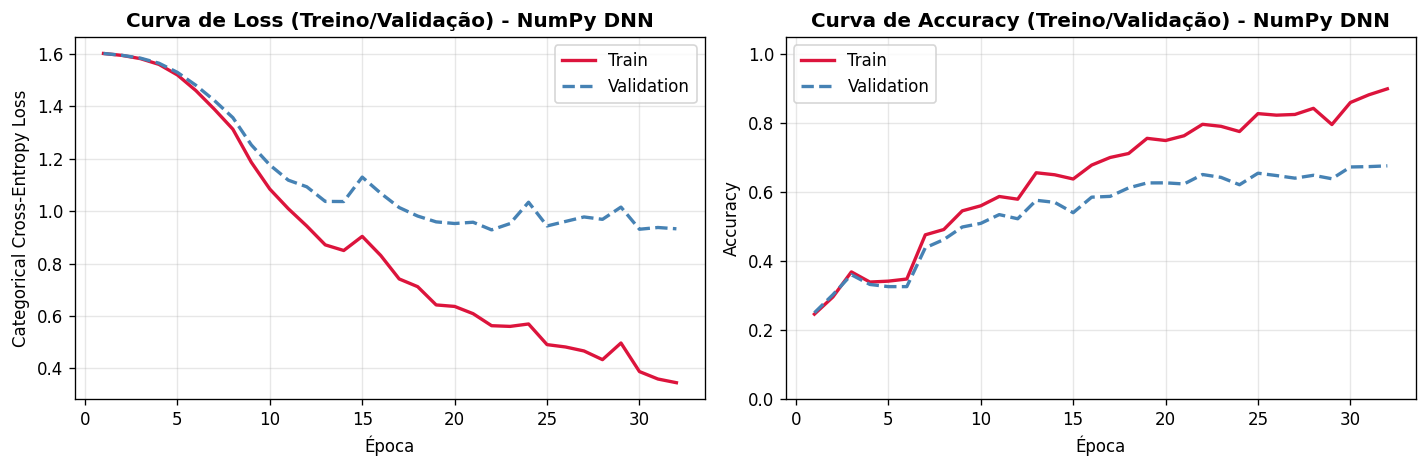

In [7]:
os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, color='crimson', linewidth=2, label='Train')
axes[0].plot(epochs_range, val_losses, color='steelblue', linewidth=2, linestyle='--', label='Validation')
axes[0].set_title("Curva de Loss (Treino/Validação) - NumPy DNN", fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Categorical Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accs, color='crimson', linewidth=2, label='Train')
axes[1].plot(epochs_range, val_accs, color='steelblue', linewidth=2, linestyle='--', label='Validation')
axes[1].set_title("Curva de Accuracy (Treino/Validação) - NumPy DNN", fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/numpy_training_curves.png", bbox_inches='tight')
plt.show()

## 5. Avaliação no Conjunto de Teste

In [8]:
# Inferência no teste
preds_probs = net.predict(X_test)
preds_idx = np.argmax(preds_probs, axis=1)

# Loss no teste
test_loss = CategoricalCrossEntropy().loss(y_test, preds_probs)

# Métricas NumPy
cm = confusion_matrix_np(y_test_idx, preds_idx, n_classes=len(le.classes_))
test_acc = accuracy_np(y_test_idx, preds_idx)
macro = macro_metrics(cm)
weighted_f1_score = weighted_f1(cm)
bal_acc = balanced_accuracy(cm)

print("=" * 55)
print("         AVALIAÇÃO NO CONJUNTO DE TESTE - NumPy DNN")
print("=" * 55)
print(f"  Test Loss              : {test_loss:.4f}")
print(f"  Test Accuracy          : {test_acc:.4f}")
print(f"  Balanced Accuracy      : {bal_acc:.4f}")
print(f"  Macro F1-Score         : {macro['macro_f1']:.4f}")
print(f"  Weighted F1-Score      : {weighted_f1_score:.4f}")
print(f"  Macro Precision        : {macro['macro_precision']:.4f}")
print(f"  Macro Recall           : {macro['macro_recall']:.4f}")
print("=" * 55)

print_classification_report(cm, le.classes_)

         AVALIAÇÃO NO CONJUNTO DE TESTE - NumPy DNN
  Test Loss              : 0.9139
  Test Accuracy          : 0.6503
  Balanced Accuracy      : 0.6503
  Macro F1-Score         : 0.6491
  Weighted F1-Score      : 0.6491
  Macro Precision        : 0.6522
  Macro Recall           : 0.6503

Classification report (NumPy):
class         precision     recall   f1-score    support
Human            0.7640     0.8755     0.8159        795
Google           0.6204     0.6415     0.6308        795
Meta             0.6193     0.6201     0.6197        795
OpenAI           0.4570     0.4541     0.4555        795
Anthropic        0.8003     0.6604     0.7236        795


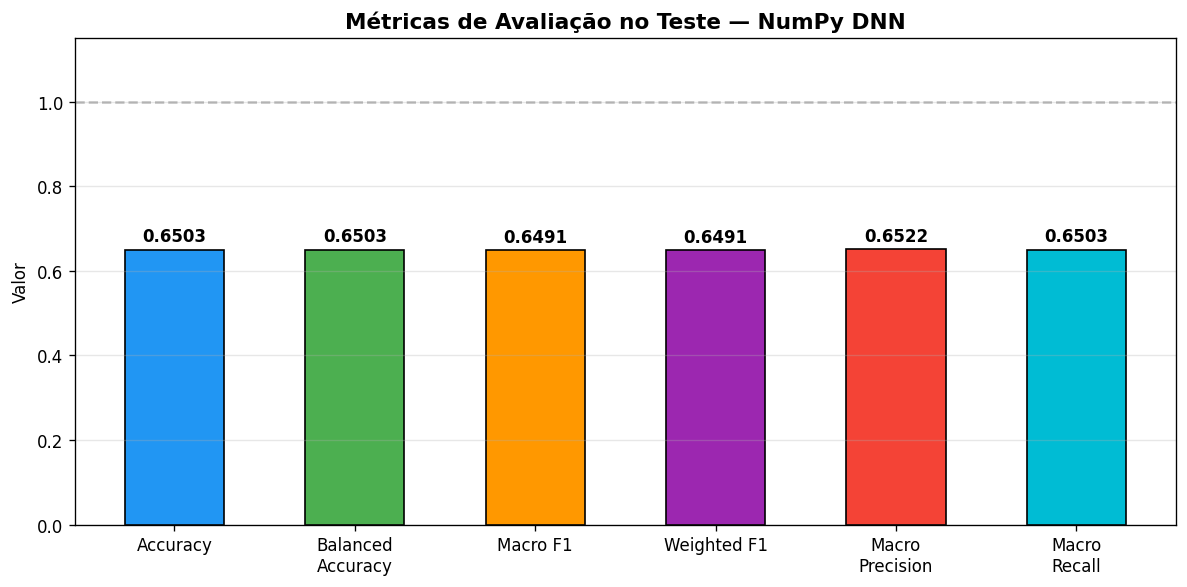

In [9]:
# Gráfico de barras das métricas
metrics_names  = ["Accuracy", "Balanced\nAccuracy", "Macro F1", "Weighted F1", "Macro\nPrecision", "Macro\nRecall"]
metrics_values = [
    test_acc,
    bal_acc,
    macro["macro_f1"],
    weighted_f1_score,
    macro["macro_precision"],
    macro["macro_recall"],
]
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='black', width=0.55)
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title("Métricas de Avaliação no Teste — NumPy DNN", fontsize=13, fontweight='bold')
ax.set_ylabel("Valor")
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/numpy_test_metrics.png", bbox_inches='tight')
plt.show()

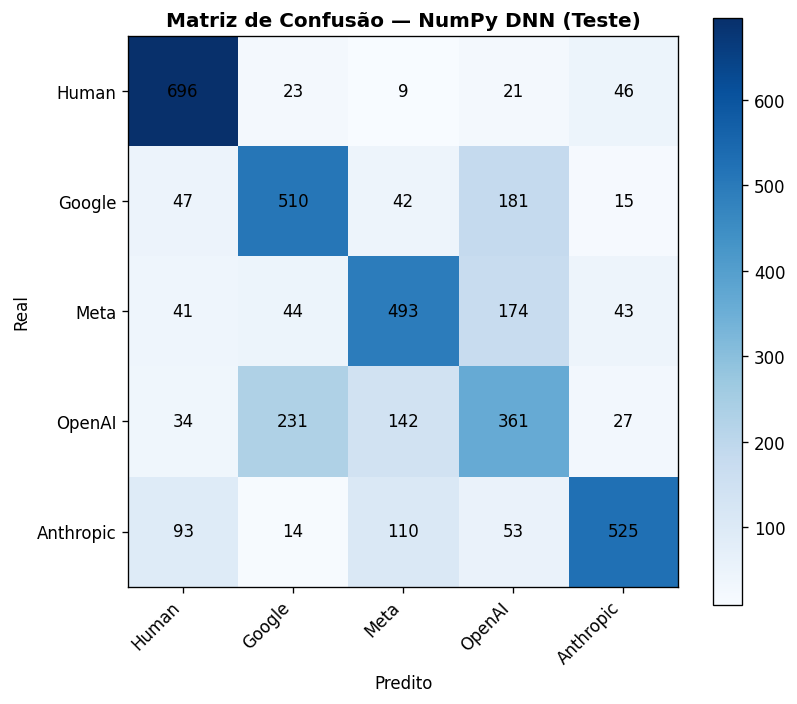

In [10]:
# Matriz de Confusão (NumPy)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(le.classes_)))
ax.set_yticks(np.arange(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticklabels(le.classes_)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — NumPy DNN (Teste)", fontsize=12, fontweight='bold')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig("plots/numpy_confusion_matrix.png", bbox_inches='tight')
plt.show()

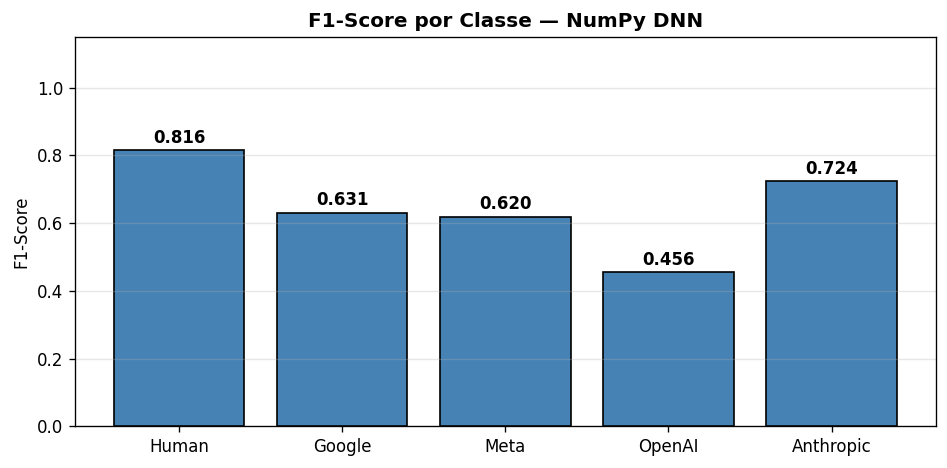

In [11]:
# F1-Score por classe (NumPy)
_, _, f1_per_class, _ = per_class_precision_recall_f1(cm)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(le.classes_, f1_per_class, color='steelblue', edgecolor='black')
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title("F1-Score por Classe — NumPy DNN", fontsize=12, fontweight='bold')
ax.set_ylabel("F1-Score")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/numpy_f1_per_class.png", bbox_inches='tight')
plt.show()

## 6. Guardar Modelo e Artefactos

In [12]:
# Guardar artefactos e métricas
numpy_metrics = {
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "balanced_accuracy": bal_acc,
    "macro_f1": macro["macro_f1"],
    "weighted_f1": weighted_f1_score,
    "macro_precision": macro["macro_precision"],
    "macro_recall": macro["macro_recall"],
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accs": train_accs,
    "val_accs": val_accs,
    "baseline_accuracy": baseline_acc,
    "baseline_macro_f1": baseline_macro["macro_f1"]
}

with open("modelo_numpy_artefactos.pkl", "wb") as f:
    pickle.dump({
        "model": net,
        "baseline_model": baseline,
        "vocab": vocab,
        "idf": idf,
        "label_encoder": le,
        "classes": list(le.classes_),
        "metrics": numpy_metrics
    }, f)

print("Artefactos NumPy guardados com sucesso!")
print(f"\nResumo Final — NumPy DNN:")
print(f"  Macro F1   : {macro['macro_f1']:.4f}")
print(f"  Accuracy   : {test_acc:.4f}")
print(f"  Bal. Acc   : {bal_acc:.4f}")
print(f"\nResumo Baseline — Regressão Logística NumPy:")
print(f"  Macro F1   : {baseline_macro['macro_f1']:.4f}")
print(f"  Accuracy   : {baseline_acc:.4f}")

Artefactos NumPy guardados com sucesso!

Resumo Final — NumPy DNN:
  Macro F1   : 0.6491
  Accuracy   : 0.6503
  Bal. Acc   : 0.6503

Resumo Baseline — Regressão Logística NumPy:
  Macro F1   : 0.5472
  Accuracy   : 0.5530
